# Action precedents from Chile BIP projects

**Question.** Taking only the **strong** project→action matches, what does that tell us about each mitigation **action** — which actions have a real-world **precedent** in Chile, and what can the underlying FICHA documents offer someone who wants to **build a new project from an action**? And, honestly: **what is possible with this data and what is not?**

**Data** (from `cl-ssg-projects` derived outputs, `../data/derived/`):
- `project_action_matches.csv` — project→action matches with labels/overlaps.
- `projects_profiled.csv` — one row per project, profiled.
- `ficha_idi_table_translated.csv` — parsed FICHA IDI fields (per *etapa*), ES+EN.
- `actions_profiled.csv` — the 102-action mitigation library.

**Definitions.**
- *Strong match*: best candidate shares **outcome + intervention + channel** with the project (the tightest tier). We use only `rank==1, label=="strong"`.
- *Precedent*: an action has a precedent if ≥1 real Chilean project strongly matches it.

> Note: this runs on the SSG PDF-derived data as the working set. The same analysis applies to the BIDAT-sourced `cl-bip-projects` table once pulled.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 60); pd.set_option('display.width', 140)
D = '../data/derived/'
m  = pd.read_csv(D+'project_action_matches.csv', dtype={'codigo_bip':str})
pp = pd.read_csv(D+'projects_profiled.csv', dtype={'codigo_bip':str})
a  = pd.read_csv(D+'actions_profiled.csv')
t  = pd.read_csv(D+'ficha_idi_table_translated.csv', dtype={'bip_code':str})

# normalize BIP join key to digits only
for df,c in [(m,'codigo_bip'),(pp,'codigo_bip'),(t,'bip_code')]:
    df['k'] = df[c].str.extract(r'(\d+)')[0]
a.columns = [c.lstrip('\ufeff') for c in a.columns]
print('rows:', dict(matches=len(m), projects=len(pp), ficha_etapas=len(t), actions=len(a)))


rows: {'matches': 8336, 'projects': 3144, 'ficha_etapas': 7086, 'actions': 102}


## Strong matches only

In [2]:
strong = m[(m['rank']==1) & (m['label']=='strong')].copy()
print('strong matches:', len(strong), '| distinct projects:', strong['k'].nunique(),
      '| distinct actions hit:', strong['action_id'].nunique(), 'of', len(a))


strong matches: 717 | distinct projects: 717 | distinct actions hit: 29 of 102


## 1 · Which actions have a precedent?

How many of the 102 mitigation actions are backed by at least one strong real project, and how concentrated are the precedents?

In [3]:
by_action = (strong.groupby(['action_id','action_name']).size()
             .reset_index(name='n_precedents').sort_values('n_precedents', ascending=False))
n_with = by_action['action_id'].nunique()
print(f'Actions WITH ≥1 strong precedent: {n_with} of {len(a)} ({n_with/len(a)*100:.0f}%)')
print(f'Actions WITHOUT any strong precedent: {len(a)-n_with}')
print('\nTop 15 actions by number of precedents:')
display(by_action.head(15).reset_index(drop=True))


Actions WITH ≥1 strong precedent: 29 of 102 (28%)
Actions WITHOUT any strong precedent: 73

Top 15 actions by number of precedents:


,action_id,action_name,n_precedents
0,ipcc_0105,Promote active mobility through road space reallocation,210
1,icare_0040,Deploy energy-efficient and solar-powered street lightin...,131
2,icare_0012,Expand solar energy generation on municipal facilities a...,94
3,c40_0036,Upgrade Landfills to Engineered Sanitary Landfills with ...,62
4,c40_0042,Expand urban and peri-urban green spaces,40
5,icare_0122,Establish eco-parks.,37
6,icare_0137,Replace Inefficient Lighting with LED Technology in Publ...,30
7,icare_0053,Support cooperatives of voluntary waste collectors to ag...,27
8,ipcc_0053,"Implement afforestation, reforestation, and forest ecosy...",24
9,ipcc_0068,Pilot Bioenergy with Carbon Capture in Partnership with ...,14


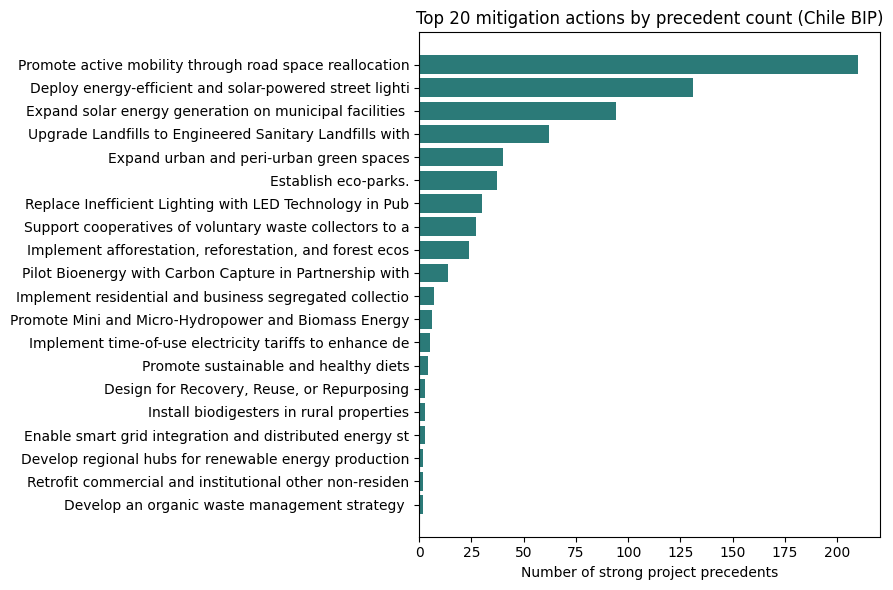

In [4]:
fig, ax = plt.subplots(figsize=(9,6))
top = by_action.head(20).iloc[::-1]
ax.barh(top['action_name'].str.slice(0,55), top['n_precedents'], color='#2b7a78')
ax.set_xlabel('Number of strong project precedents'); ax.set_title('Top 20 mitigation actions by precedent count (Chile BIP)')
plt.tight_layout(); plt.show()


In [5]:
# Actions with NO precedent — the gaps in real-world implementation
have = set(by_action['action_id'])
no_prec = a[~a['action_id'].isin(have)][['action_id','action_name']]
print(f'{len(no_prec)} actions have no strong precedent. Examples:')
display(no_prec.head(20).reset_index(drop=True))


73 actions have no strong precedent. Examples:


,action_id,action_name
0,c40_0010,Introduce energy-efficiency standards for new residentia...
1,c40_0012,Introduce energy-efficiency standards for new institutio...
2,c40_0013,Support Implementation of Industrial Building Efficiency...
3,c40_0017,Retrofit municipal buildings for energy efficiency
4,c40_0018,Optimize energy efficiency and sustainability standards ...
5,c40_0023,Adopt zero-emission bus fleets for public transport
6,c40_0025,Promote deployment of zero-emission freight fleets (trucks)
7,c40_0029,Electrify municipal vehicle fleets
8,c40_0034,Enact and enforce material bans in order to restrict sin...
9,c40_0040,Implement Volume-Based Collection policy


## 2 · What do the precedents tell us about each action?

For each action with precedents, the FICHA documents of its precedent projects give real **cost, funding mix, lead agency, beneficiary scale, and schedule**. Coverage varies a lot by field — we quantify that first, because it bounds what's usable.

In [6]:
# one FICHA row per project (latest etapa), joined to its strong action
tl = t.sort_values('etapa_index').groupby('k').tail(1)
sj = strong.merge(tl, on='k', how='left', suffixes=('','_f'))
print('strong projects with a FICHA row:', sj['components_es'].index.size,
      '->', sj['total_cost_CLP'].notna().sum(), 'have cost')

cov_fields = {'total_cost_M_CLP_thousands':'total cost','funding_sources':'funding sources',
              'lead_agency':'lead agency','schedule_summary':'schedule','beneficiaries_total':'beneficiaries',
              'conclusions_es':'analyst conclusions','review_result_code':'RATE result',
              'components_es':'component breakdown','duration_months':'duration (months)',
              'purpose_indicators_es':'purpose indicators'}
cov = pd.DataFrame({'field':list(cov_fields.values()),
        'pct_of_strong_precedents': [round(sj[c].notna().mean()*100,1) for c in cov_fields]}
      ).sort_values('pct_of_strong_precedents', ascending=False)
display(cov.reset_index(drop=True))


strong projects with a FICHA row: 717 -> 615 have cost


,field,pct_of_strong_precedents
0,total cost,85.8
1,funding sources,85.8
2,lead agency,85.8
3,schedule,85.8
4,beneficiaries,82.6
5,analyst conclusions,51.6
6,RATE result,34.7
7,component breakdown,11.6
8,duration (months),11.6
9,purpose indicators,11.6


In [7]:
# Per-action precedent profile, using the well-covered fields
def top_mode(s):
    s = s.dropna()
    return s.value_counts().index[0] if len(s) else None
sj['cost_clp_num'] = pd.to_numeric(sj['total_cost_CLP'], errors='coerce')
sj['ben_num'] = pd.to_numeric(sj['beneficiaries_total'], errors='coerce')

prof = (sj.groupby('action_name')
        .agg(n_precedents=('k','nunique'),
             median_cost_CLP=('cost_clp_num','median'),
             median_beneficiaries=('ben_num','median'),
             typical_funding=('funding_sources', top_mode),
             typical_lead_agency=('lead_agency', top_mode))
        .reset_index().sort_values('n_precedents', ascending=False))
prof['median_cost_MM_CLP'] = (prof['median_cost_CLP']/1e6).round(1)
display(prof[['action_name','n_precedents','median_cost_MM_CLP','median_beneficiaries',
             'typical_funding','typical_lead_agency']].head(15).reset_index(drop=True))


,action_name,n_precedents,median_cost_MM_CLP,median_beneficiaries,typical_funding,typical_lead_agency
0,Promote active mobility through road space reallocation,210,296.4,17880.5,Sectoral (line-ministry budget),SEREMI VIVIENDA REGION DEL BIO BIO
1,Deploy energy-efficient and solar-powered street lightin...,131,89.6,3169.5,FNDR (Regional Development Fund),MUNICIPALIDAD DE LOS ALAMOS
2,Expand solar energy generation on municipal facilities a...,94,193.1,409.0,FNDR (Regional Development Fund),SEREMI DE ENERGIA REGION DE ARICA Y PARINACOTA
3,Upgrade Landfills to Engineered Sanitary Landfills with ...,62,417.1,17365.0,FNDR (Regional Development Fund),GOBIERNO REGIONAL - REGION DE AISEN DEL GENERAL CARLOS I...
4,Expand urban and peri-urban green spaces,40,150.2,8913.5,FNDR (Regional Development Fund),MUNICIPALIDAD DE PARRAL
5,Establish eco-parks.,37,297.0,25433.5,FNDR (Regional Development Fund),GOBIERNO REGIONAL - REGION DE ANTOFAGASTA
6,Replace Inefficient Lighting with LED Technology in Publ...,30,143.4,5156.0,FNDR (Regional Development Fund),MUNICIPALIDAD DE CURACAVI
7,Support cooperatives of voluntary waste collectors to ag...,27,380.0,3783.5,FNDR (Regional Development Fund),GOBIERNO REGIONAL - REGION DE LA ARAUCANIA
8,"Implement afforestation, reforestation, and forest ecosy...",24,402.9,400.0,FNDR (Regional Development Fund),CORPORACION NACIONAL FORESTAL REGION DE AISEN DEL GENERA...
9,Pilot Bioenergy with Carbon Capture in Partnership with ...,14,386.9,130.0,FNDR (Regional Development Fund),CORPORACION NACIONAL FORESTAL REGION DE AISEN DEL GENERA...


## 3 · "Build a project from an action" — reference card demo

For a well-covered action, the precedent projects act as a template: real cost, who runs it, how it's funded, how big, and (where present) what components it includes. Below is a worked example.

In [8]:
def reference_card(action_substr, n=4):
    sel = sj[sj['action_name'].str.contains(action_substr, case=False, na=False)]
    if not len(sel): print('no match'); return
    act = sel['action_name'].iloc[0]
    print('='*88); print('ACTION:', act); print(f'Precedents (strong): {sel.k.nunique()}')
    arow = a[a['action_name']==act]
    if len(arow):
        ar = arow.iloc[0]
        print('Library guidance — investment_cost: %s | timeline: %s | emissions_impact: %s'
              % (ar.get('investment_cost'), ar.get('implementation_timeline'), ar.get('emissions_impact_text')))
    c = pd.to_numeric(sel['total_cost_CLP'], errors='coerce')/1e6
    print('Precedent cost (MM CLP): median %.0f | range %.0f–%.0f' % (c.median(), c.min(), c.max()))
    print('-'*88, '\nEXAMPLE PRECEDENT PROJECTS:')
    for _,r in sel.head(n).iterrows():
        print('  •', str(r['nombre'])[:78])
        print('      region:', r.get('location_name'), '| lead:', str(r.get('lead_agency'))[:40],
              '| cost MM CLP: %.0f'%(pd.to_numeric(pd.Series([r['total_cost_CLP']]),errors='coerce').iloc[0]/1e6
                                     if pd.notna(r['total_cost_CLP']) else float('nan')))
        print('      funding:', str(r.get('funding_sources'))[:60], '| beneficiaries:', r.get('beneficiaries_total'))
        comp = r.get('components_es')
        if pd.notna(comp): print('      components:', str(comp)[:160])

reference_card('street lighting')


ACTION: Deploy energy-efficient and solar-powered street lighting across all neighborhoods
Precedents (strong): 131
Library guidance — investment_cost: medium | timeline: 5-10 years | emissions_impact: very low
Precedent cost (MM CLP): median 90 | range 0–16723
---------------------------------------------------------------------------------------- 
EXAMPLE PRECEDENT PROJECTS:
  • ADQUISICION INSTALACION ALUMBRADO PUBLICO SOLAR COMUNA DE PENCAHUE
      region: PENCAHUE | lead: MUNICIPALIDAD DE PENCAHUE | cost MM CLP: 24
      funding: FNDR (Regional Development Fund) | beneficiaries: 3300.0
  • CONSTRUCCION ALUMBRADO Y PLANTA SOLAR CON CONEXION A RED, PETORCA
      region: PETORCA | lead: MUNICIPALIDAD DE PETORCA | cost MM CLP: 100
      funding: FNDR (Regional Development Fund) | beneficiaries: 588.0
  • ADQUISICION LUMINARIAS FOTOVOLTAICAS, COMUNA LLAY LLAY
      region: LLAY LLAY | lead: MUNICIPALIDAD DE LLAY LLAY | cost MM CLP: 118
      funding: FNDR (Regional Development Fund) | 

In [9]:
reference_card('Landfills')

ACTION: Upgrade Landfills to Engineered Sanitary Landfills with Gas Capture.
Precedents (strong): 62
Library guidance — investment_cost: medium | timeline: <5 years | emissions_impact: very low
Precedent cost (MM CLP): median 417 | range 25–14492
---------------------------------------------------------------------------------------- 
EXAMPLE PRECEDENT PROJECTS:
  • CONSTRUCCION RELLENO SANITARIO COMUNA DE MEJILLONES
      region: MEJILLONES | lead: MUNICIPALIDAD DE MEJILLONES | cost MM CLP: 46
      funding: FNDR (Regional Development Fund) | beneficiaries: 0.0
  • NORMALIZACION Y RECUPERACION AREAS EX VERTEDERO LO ERRAZURIZ 2°ETAPA
      region: ESTACION CENTRAL | lead: GOBIERNO REGIONAL - REGION METROPOLITANA | cost MM CLP: 2278
      funding: FNDR (Regional Development Fund) | beneficiaries: 346722.0
  • CONSTRUCCION OBRAS PLAN DE CIERRE VERTEDERO BOYECO, TEMUCO
      region: TEMUCO | lead: MUNICIPALIDAD DE TEMUCO | cost MM CLP: 3981
      funding: FNDR (Regional Development Fund) 

## 4 · What's possible and what's not

Grounded in the coverage table from Section 2 (share of strong precedents with each field populated).

In [10]:
poss = cov.copy()
poss['verdict'] = np.where(poss['pct_of_strong_precedents']>=80,'POSSIBLE (robust)',
                   np.where(poss['pct_of_strong_precedents']>=40,'PARTIAL (illustrative)','LIMITED (sparse)'))
display(poss.reset_index(drop=True))


,field,pct_of_strong_precedents,verdict
0,total cost,85.8,POSSIBLE (robust)
1,funding sources,85.8,POSSIBLE (robust)
2,lead agency,85.8,POSSIBLE (robust)
3,schedule,85.8,POSSIBLE (robust)
4,beneficiaries,82.6,POSSIBLE (robust)
5,analyst conclusions,51.6,PARTIAL (illustrative)
6,RATE result,34.7,LIMITED (sparse)
7,component breakdown,11.6,LIMITED (sparse)
8,duration (months),11.6,LIMITED (sparse)
9,purpose indicators,11.6,LIMITED (sparse)


**Possible with this data (≈100% coverage of strong precedents):**
- *Which actions have a precedent* and how common — a real implementation-frequency signal across Chile.
- Per-action **cost benchmarks** (total cost, and cost per beneficiary), **funding mix** (FNDR / sectorial / municipal), **lead/responsible agency** type, **beneficiary scale**, and **schedule** — i.e. a realistic "what it costs, who runs it, how it's funded, how big" reference built from precedents.
- Qualitative **why/what** from justification & description (≈82% of ficha projects) and the analyst's **conclusions** (~60%) and **RATE** approval signal (~40%).

**Partial / illustrative only:**
- **Component-level build specs**, **purpose indicators**, explicit **duration in months** — present for only ~13% of strong precedents. You can show worked examples per action, but not robust per-action distributions.

**Not possible from this data alone:**
- Engineering/design specifications, BoQ, or procurement detail to actually construct.
- Quantified **emissions impact** per action (the library carries only categorical bands like "very low"; the FICHA has no emissions figures).
- Reliable city/comuna geography for all projects (location is sparse upstream).

**Bottom line.** This data is strong for a *precedent and benchmarking* tool — "show me Chilean projects that implemented this action, what they cost, who ran them, how they were funded" — and for a qualitative starter brief. It is **not** an engineering or emissions-quantification source. The build-spec layer (components/indicators) exists but is too sparse to rely on beyond examples.


## 5 · Triage — are the "missing" actions recoverable or genuinely absent?

Every action that lacks a rank-1 strong precedent is classified into one of three buckets, so we have a concrete worklist of what to chase versus accept:

- **precedent_rank1** — already has a strong precedent at rank 1 (nothing to do).
- **recount_recoverable** — has a strong match at rank 2–5 only; surfaces just by counting strong at *any* rank.
- **matcher_miss** — no strong at any rank, but appears as a `compatible_context` / `goal_aligned` candidate for real projects → recoverable by loosening the matcher (relax the 3-facet rule, handle outcome-actions, embedding re-rank).
- **genuinely_absent** — never a candidate at all (no facet overlap), or only `wrong_scope`/`unrelated` → out of scope for a public-investment registry (mostly industrial/private).


In [11]:
# classify all 102 actions
strong_r1  = set(m[(m['rank']==1) & (m['label']=='strong')]['action_id'])
strong_any = set(m[m['label']=='strong']['action_id'])

appear = m.groupby('action_id')
times_candidate = appear.size()
best_label = appear['label'].agg(lambda s: s.dropna().value_counts().index[0] if s.notna().any() else None)
strong_any_count = m[m['label']=='strong'].groupby('action_id')['k'].nunique()

def bucket(aid):
    if aid in strong_r1: return 'precedent_rank1'
    if aid in strong_any: return 'recount_recoverable'
    bl = best_label.get(aid)
    if bl in ('compatible_context','goal_aligned'): return 'matcher_miss'
    return 'genuinely_absent'   # never a candidate, or only wrong_scope/unrelated

tri = a[['action_id','action_name']].copy()
tri['bucket'] = tri['action_id'].map(bucket)
tri['strong_precedents_any_rank'] = tri['action_id'].map(strong_any_count).fillna(0).astype(int)
tri['times_as_candidate'] = tri['action_id'].map(times_candidate).fillna(0).astype(int)
tri['best_candidate_label'] = tri['action_id'].map(best_label).fillna('never_a_candidate')

order = {'precedent_rank1':0,'recount_recoverable':1,'matcher_miss':2,'genuinely_absent':3}
tri = tri.sort_values([tri['bucket'].map(order).name if False else 'bucket','times_as_candidate'],
                      key=lambda col: col.map(order) if col.name=='bucket' else col,
                      ascending=[True,False])
print('Bucket counts (all 102 actions):')
print(tri['bucket'].value_counts().reindex(list(order)).to_string())


Bucket counts (all 102 actions):
bucket
precedent_rank1        29
recount_recoverable     9
matcher_miss           37
genuinely_absent       27


In [12]:
# RECOUNT-RECOVERABLE: strong precedent exists at rank>1 — count it and you gain these
display(tri[tri['bucket']=='recount_recoverable']
        [['action_name','strong_precedents_any_rank','best_candidate_label']].reset_index(drop=True))


,action_name,strong_precedents_any_rank,best_candidate_label
0,Promote compact urban form and transit-oriented development,1,compatible_context
1,Retrofit municipal buildings for energy efficiency,2,compatible_context
2,Promote Net-Zero and Green Building Certifications,3,compatible_context
3,Establish Municipal Programs for Payment for Environment...,1,compatible_context
4,Create financing programs for local renewable energy pro...,3,compatible_context
5,Support research into carbon-neutral manufacturing techn...,1,compatible_context
6,Encourage the Use of Zero-Emission Fuels in Industrial P...,1,compatible_context
7,Promote consumer behavior focused on sufficiency and red...,1,compatible_context
8,Create tax incentives for companies adopting clean techn...,1,strong


In [13]:
# MATCHER-MISS: real projects relate but never scored strong — the worklist to chase
display(tri[tri['bucket']=='matcher_miss']
        [['action_name','times_as_candidate','best_candidate_label']].reset_index(drop=True))


,action_name,times_as_candidate,best_candidate_label
0,Incentive to create bike-sharing programs in urban areas...,426,compatible_context
1,Implement congestion pricing and restrictions on high-po...,391,compatible_context
2,Improve public transport systems to promote modal shift,369,goal_aligned
3,Regulate Construction and Demolition Waste Management to...,222,compatible_context
4,"Implement fire management in forests, grasslands, and sa...",112,compatible_context
5,Create partnerships to implement biochar plants.,103,compatible_context
6,Promote deployment of zero-emission freight fleets (trucks),86,compatible_context
7,Electrify municipal vehicle fleets,54,goal_aligned
8,Adopt zero-emission bus fleets for public transport,53,goal_aligned
9,Enact and enforce material bans in order to restrict sin...,42,compatible_context


In [14]:
# GENUINELY-ABSENT: out of scope for a public-investment registry (mostly industrial/private)
display(tri[tri['bucket']=='genuinely_absent'][['action_name','times_as_candidate']].reset_index(drop=True))


,action_name,times_as_candidate
0,Enhance industrial energy efficiency processes,2
1,Protect and Restore Coastal Wetlands,1
2,Introduce energy-efficiency standards for new institutio...,0
3,Support Implementation of Industrial Building Efficiency...,0
4,Optimize energy efficiency and sustainability standards ...,0
5,Improve heat and energy recovery,0
6,Improve Fuel Supply Systems for Industrial Heating,0
7,Increase efficiency of industrial furnaces and kilns,0
8,Improve Heat Recovery and Reuse through Heat Exchanger N...,0
9,Adopt industrial energy efficiency technologies,0


In [15]:
# export the worklist
tri.to_csv('action_triage.csv', index=False)
print('wrote action_triage.csv (%d actions)' % len(tri))
print(tri['bucket'].value_counts().to_dict())


wrote action_triage.csv (102 actions)
{'matcher_miss': 37, 'precedent_rank1': 29, 'genuinely_absent': 27, 'recount_recoverable': 9}


**How to read this.**
- **recount_recoverable** + **matcher_miss** together are the *recoverable* set — coverage that better counting/matching would surface. Start with recount (free), then the matcher_miss transport actions (highest project counts).
- **genuinely_absent** is the *accept* set — predominantly industrial decarbonization, which a municipal/regional public-investment bank like BIP structurally does not contain. Chasing more BIP examples won't help here; these need an industrial/private source or development-bank documentation (cf. `other_projects`).

The exported `action_triage.csv` is the worklist.
